# PCOS detection - comparing a classic CV pipeline with a simple CNN

In [364]:
# imports
# data
import kagglehub

# system
import os
from pathlib import Path

# processing
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import random
import itertools
import PIL
from PIL import Image
from torch.utils.data import Subset, ConcatDataset
from typing import Tuple, List, Optional
import seaborn as sns

# models
import cv2
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Optimizer
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc
import optuna
import tqdm
from tqdm import tqdm

In [406]:
sns.set_theme(style="white", palette="pastel")
sns.set_context("notebook", font_scale=1.2)

## Preprocess data

In [4]:
# download data
path = kagglehub.dataset_download("anaghachoudhari/pcos-detection-using-ultrasound-images", force_download=False)

In [5]:
def valid(path):
        try:
            filename = os.path.basename(path)
            if not filename.lower().startswith("img"):
                return False
            with Image.open(path) as img:
                img.verify()
            return True
        except Exception:
            return False


In [6]:
for p in Path(path).rglob('*'):
    if p.is_file():
        ok = valid(str(p))
        if not ok:
            print(f"Deleting: {p.name}")
            p.unlink()

In [445]:
class Prep:
    def __init__(self, path: str, output_size=224) -> None:
        self.path = path

        actual_root = None
        for root, dirs, files in os.walk(path):
            if 'train' in dirs and 'test' in dirs:
                actual_root = root
                break
        
        if not actual_root:
            raise FileNotFoundError(f"Could not find 'train/test' in {path}")

        self.output_size = output_size

        self.train_path = os.path.join(actual_root, "train")
        #self.test_path = os.path.join(actual_root, "test")

        self.cnn = self.import_data_cnn()
        self.cv = self.import_data_cv()

        self.train_cv, self.test_cv, self.val_cv = self.split_data(self.cv)
        self.train_cnn, self.test_cnn, self.val_cnn = self.split_data(self.cnn)

    def split_data(self, dataset, class_split_at=780) -> None:

        infected = Subset(dataset, list(range(class_split_at)))
        healthy = Subset(dataset, list(range(class_split_at, len(dataset))))

        full_dataset = ConcatDataset([infected, healthy])

        n_infected = len(infected)
        n_healthy = len(healthy)

        train_idx = list(range(0, int(0.8 * n_infected))) + list(range(n_infected, n_infected + int(0.8 * n_healthy)))
        val_idx   = list(range(int(0.8 * n_infected), int(0.9 * n_infected))) + list(range(n_infected + int(0.8 * n_healthy), n_infected + int(0.9 * n_healthy)))
        test_idx  = list(range(int(0.9 * n_infected), n_infected)) + list(range(n_infected + int(0.9 * n_healthy), n_infected + n_healthy))

        random.seed(42)
        random.shuffle(train_idx)
        random.shuffle(val_idx)
        random.shuffle(test_idx)

        train_set = Subset(full_dataset, train_idx)
        val_set   = Subset(full_dataset, val_idx)
        test_set  = Subset(full_dataset, test_idx)

        return train_set, test_set, val_set        

    def cv_loader(self, img_path):
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            return np.zeros((self.output_size, self.output_size), dtype=np.uint8)
        
        return cv2.resize(img, (self.output_size, self.output_size))

    def import_data_cv(self):
        return datasets.ImageFolder(self.train_path, loader=self.cv_loader)

    def import_data_cnn(self):
        transform = transforms.Compose([transforms.ToPILImage(), transforms.ToTensor()])
        loader = lambda x: self.cv_loader(x)
        return datasets.ImageFolder(self.train_path, loader=loader, transform=transform)
    
    def display_examples(self):
        fig, ax = plt.subplots(1, 2, figsize=(10, 5))

        infected_example, _ = self.train_cnn[2]
        not_infected_example, _ = self.train_cnn[1]

        ax[0].imshow(infected_example.permute(1, 2, 0), cmap="gray")
        ax[0].set_title("Infected")

        ax[1].imshow(not_infected_example.permute(1, 2, 0), cmap="gray")
        ax[1].set_title("Not Infected")

        plt.show()

In [424]:
P = Prep(path)

## A quick look at the data

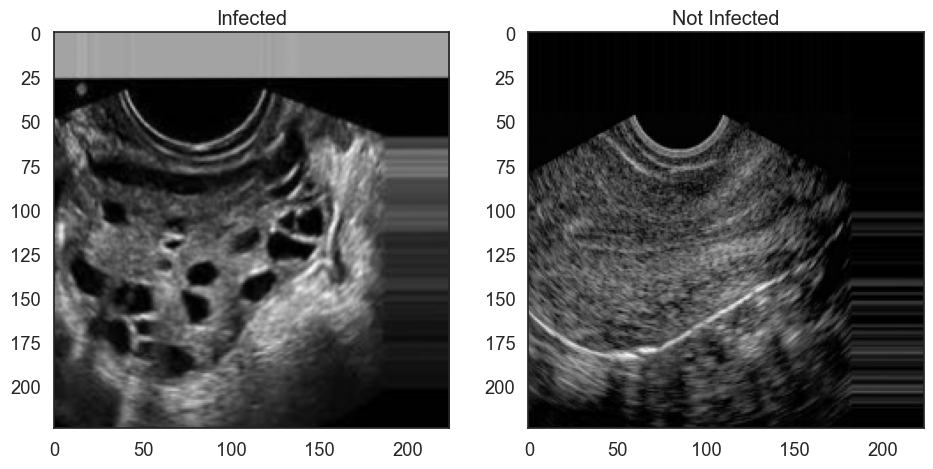

In [425]:
P.display_examples()

## Classic CV Model

In [ ]:
class Annotate:
    def __init__(self):
        pass

    @staticmethod
    def intensity_transformation(img, gamma=1.0):
        """Enhances details in shadowed areas (if gamma > 1)."""
        invGamma = 1.0 / gamma
        table = np.array([((i / 255.0) ** invGamma) * 255 
                          for i in np.arange(0, 256)]).astype("uint8")
        return cv2.LUT(img, table)
    
    @staticmethod
    def apply_clahe(img, clip=2.0, tile=(8, 8)):
        """Applies localised histogram equalisation."""
        clahe_obj = cv2.createCLAHE(clipLimit=clip, tileGridSize=tile)
        return clahe_obj.apply(img)
    
    @staticmethod
    def denoise(img, d=7, sigma_color=50, sigma_space=50):
        """Reduces noise while preserving sharp edges."""
        return cv2.bilateralFilter(img, d, sigma_color, sigma_space)
    
    @staticmethod
    def spatial_filtering(img, ksize=5):
        """Removes granular noise."""
        ksize = ksize if ksize % 2 != 0 else ksize + 1
        return cv2.medianBlur(img, ksize)
    
    @staticmethod
    def segment_anechoic_regions(img, thresh_val=35):
        """Creates binary mask."""
        _, binary = cv2.threshold(img, thresh_val, 255, cv2.THRESH_BINARY_INV)
        return binary
    
    @staticmethod
    def refine_mask(mask, ksize=5):
        """Remove small specles."""
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (ksize, ksize))
        refined = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
        refined = cv2.morphologyEx(refined, cv2.MORPH_CLOSE, kernel)
        return refined
    
    def annotate_mask(self, original_gray, mask, min_circularity=0.2, min_solidity=0.7, area_ratio=0.0005):
        """Finds follicules."""
        annotated = cv2.cvtColor(original_gray, cv2.COLOR_GRAY2BGR)
        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        
        h, w = original_gray.shape
        min_area = area_ratio * h * w
        count = 0
        
        for cnt in contours:
            area = cv2.contourArea(cnt)
            perimeter = cv2.arcLength(cnt, True)
            if area < min_area or perimeter == 0: continue
            
            hull = cv2.convexHull(cnt)
            hull_area = cv2.contourArea(hull)
            solidity = float(area) / hull_area if hull_area > 0 else 0
            circularity = (4 * np.pi * area) / (perimeter ** 2)
            
            if solidity > min_solidity and circularity > min_circularity:
                count += 1
                
                s_score = (solidity - min_solidity) / (1.0 - min_solidity)
                c_score = (circularity - min_circularity) / (1.0 - min_circularity)
                confidence = (s_score + c_score) / 2
                confidence = np.clip(confidence, 0, 1)

                # As confidence goes up, Green increases and Red decreases
                color = (0, int(255 * confidence), int(255 * (1 - confidence)))
                
                if len(cnt) >= 5:
                    ellipse = cv2.fitEllipse(cnt)
                    cv2.ellipse(annotated, ellipse, color, 2)
                    
                    cv2.putText(annotated, f"{confidence:.2f}", (int(ellipse[0][0]), int(ellipse[0][1])), 
                               cv2.FONT_HERSHEY_SIMPLEX, 0.4, color, 1)
    
        return annotated, count

    def apply_pipeline(self, img, 
                       gamma=1.4, clahe_clip=2.8, clahe_tile=(8,8),
                       d=4, sigma_color=51, sigma_space=71,
                       median_ksize=9, thresh_val=45, morph_ksize=9,
                       min_circularity=0.17, min_solidity=0.76,
                       area_ratio=0.0005, plot=False):
        
        steps = []
        steps.append(("Original", img))

        res_gamma = self.intensity_transformation(img, gamma=gamma)
        steps.append(("Gamma Correction", res_gamma))
        
        res_clahe = self.apply_clahe(res_gamma, clip=clahe_clip, tile=clahe_tile)
        steps.append(("CLAHE", res_clahe))
        
        res_denoise = self.denoise(res_clahe, d=d, sigma_color=sigma_color, sigma_space=sigma_space)
        res_smooth = self.spatial_filtering(res_denoise, ksize=median_ksize)
        steps.append(("Denoise & Blur", res_smooth))
        
        mask_raw = self.segment_anechoic_regions(res_smooth, thresh_val=thresh_val)
        steps.append(("Binary Mask", mask_raw))
        
        mask_refined = self.refine_mask(mask_raw, ksize=morph_ksize)
        steps.append(("Refined Mask", mask_refined))
        
        final_img, count = self.annotate_mask(img, mask_refined, 
                                              min_circularity=min_circularity, 
                                              min_solidity=min_solidity,
                                              area_ratio=area_ratio)
        steps.append((f"Final (Found: {count})", final_img))

        if plot:
            fig, axes = plt.subplots(1, len(steps), figsize=(20, 5))
            for i, (title, step_img) in enumerate(steps):
                axes[i].imshow(step_img, cmap='gray')
                axes[i].set_title(title)
                axes[i].axis('off')
            plt.tight_layout()
            plt.show()

        return final_img, count


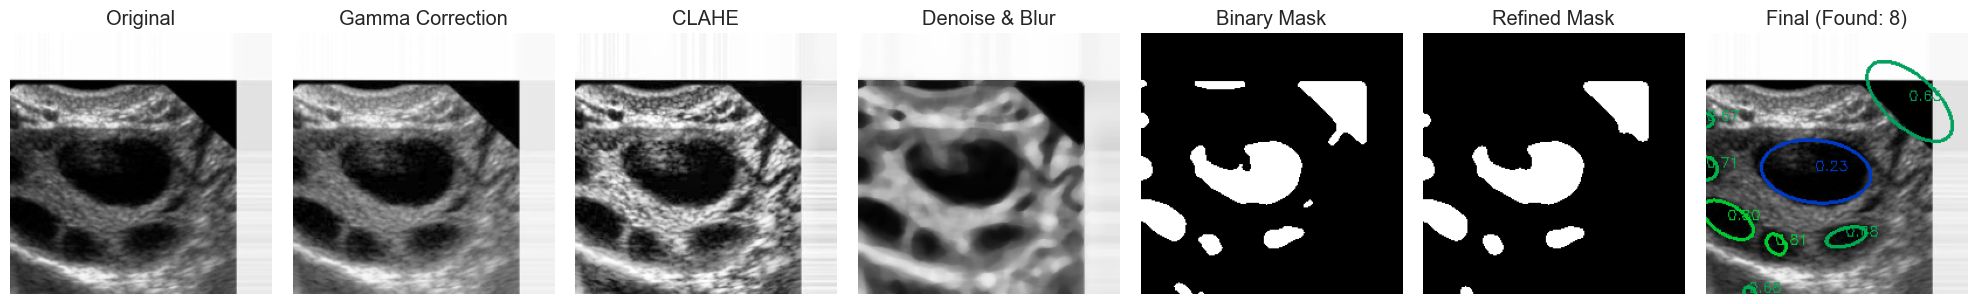

Detected 8 potential cysts.
True label: 0


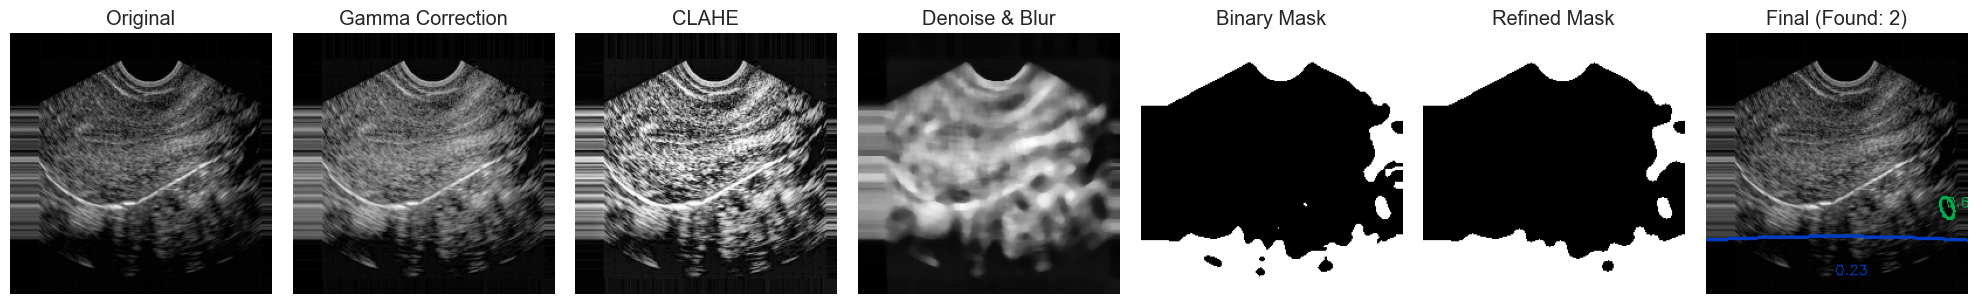

Detected 2 potential cysts.
True label: 1


In [434]:
engine = Annotate()

img, label = P.train_cv[0] 
result_img, cyst_count = engine.apply_pipeline(img, plot=True)

print(f"Detected {cyst_count} potential cysts.")
print(f"True label: {label}")

img, label = P.train_cv[-1] 
result_img, cyst_count = engine.apply_pipeline(img, plot=True)

print(f"Detected {cyst_count} potential cysts.")
print(f"True label: {label}")

In [435]:
class ManualModel:
    def __init__(self, dataset):
        self.dataset = dataset
        self.engine = Annotate()

    def infer_labels(self, threshold=7, indices=None, **kwargs):
        """
        Calculates follicle counts and predicts labels.
        **kwargs allows Optuna to pass any number of CV parameters 
        directly to the Annotate pipeline.
        """
        data = {"true_label": [], "pred_label": [], "count": [], "is_correct": []}
        target_indices = indices if indices is not None else range(len(self.dataset))

        for i in target_indices:
            img, label = self.dataset[i]

            _, count = self.engine.apply_pipeline(img, **kwargs)

            # 0 = PCOS, 1 = Healthy
            pred_label = 0 if count >= threshold else 1

            data["true_label"].append(int(label))
            data["pred_label"].append(pred_label)
            data["count"].append(count)
            data["is_correct"].append(1 if label == pred_label else 0)

        return pd.DataFrame(data)

    def evaluate(self, df):
        """Metric for Optuna to maximize."""
        if df.empty: return 0.0
        return df["is_correct"].mean()

In [436]:
MM = ManualModel(P.train_cv)
df = MM.infer_labels()
MM.evaluate(df)

0.9791937581274383

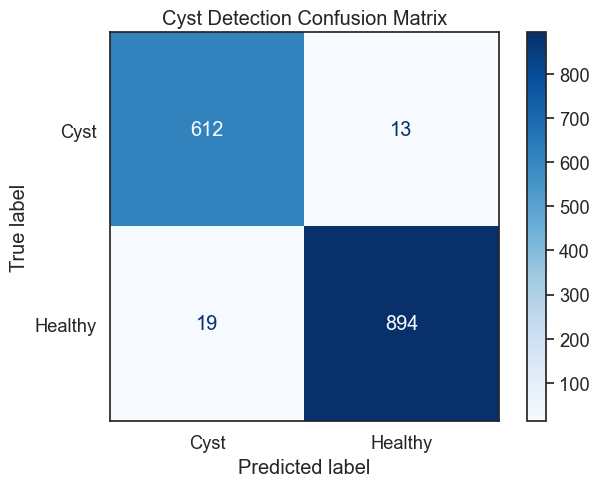

In [430]:
cm = confusion_matrix(df["true_label"], df["pred_label"])

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Cyst', 'Healthy'])
disp.plot(cmap=plt.cm.Blues)
plt.title("Cyst Detection Confusion Matrix")
plt.show()

In [431]:
def run_pcos_optimization(model_engine, n_trials=50):
    def objective(trial):
        params = {
            'gamma': trial.suggest_float('gamma', 0.8, 2.0),
            'clahe_clip': trial.suggest_float('clahe_clip', 1.0, 3.0),
            'd': trial.suggest_int('d', 3, 9),
            'sigma_color': trial.suggest_int('sigma_color', 30, 80),
            'sigma_space': trial.suggest_int('sigma_space', 30, 80),
            'median_ksize': trial.suggest_int('median_ksize', 3, 9, step=2),
            'thresh_val': trial.suggest_int('thresh_val', 20, 50),
            'morph_ksize': trial.suggest_int('morph_ksize', 3, 9, step=2),
            'min_circularity': trial.suggest_float('min_circularity', 0.1, 0.4),
            'min_solidity': trial.suggest_float('min_solidity', 0.6, 0.95),
            'area_ratio': trial.suggest_float('area_ratio', 0.0001, 0.001),
            'threshold': trial.suggest_int('threshold', 3, 15) 
        }

        total_len = len(model_engine.dataset)
        for step, size in enumerate([int(total_len * 0.1), total_len]):
            df = model_engine.infer_labels(indices=range(size), **params)
            accuracy = model_engine.evaluate(df)
            
            trial.report(accuracy, step=step)
            if trial.should_prune():
                raise optuna.TrialPruned()

        return accuracy

    study = optuna.create_study(direction="maximize", pruner=optuna.pruners.SuccessiveHalvingPruner())
    study.optimize(objective, n_trials=n_trials)
    
    return study.best_params

In [322]:
model = ManualModel(P.train_cv)
best_settings = run_pcos_optimization(model)
print("Best Settings:", best_settings)

[I 2026-03-18 15:54:32,016] A new study created in memory with name: no-name-c0649054-c8a3-42fc-9bbe-26b489b01939
[I 2026-03-18 15:54:34,020] Trial 0 finished with value: 0.5890767230169051 and parameters: {'gamma': 1.8946199180235832, 'clahe_clip': 2.010451203296234, 'd': 3, 'sigma_color': 39, 'sigma_space': 77, 'median_ksize': 5, 'thresh_val': 22, 'morph_ksize': 7, 'min_circularity': 0.2849551940547635, 'min_solidity': 0.6273561150622561, 'area_ratio': 0.00013586067531487023, 'threshold': 3}. Best is trial 0 with value: 0.5890767230169051.
[I 2026-03-18 15:54:36,522] Trial 1 finished with value: 0.6931079323797139 and parameters: {'gamma': 1.0272674023263222, 'clahe_clip': 2.8340843576610877, 'd': 7, 'sigma_color': 32, 'sigma_space': 52, 'median_ksize': 5, 'thresh_val': 41, 'morph_ksize': 5, 'min_circularity': 0.12676471765353645, 'min_solidity': 0.9230555190251275, 'area_ratio': 0.0008472541467597674, 'threshold': 11}. Best is trial 1 with value: 0.6931079323797139.
[I 2026-03-18 15

Best Settings: {'gamma': 0.9858565304178688, 'clahe_clip': 2.7255281981009314, 'd': 8, 'sigma_color': 47, 'sigma_space': 38, 'median_ksize': 9, 'thresh_val': 28, 'morph_ksize': 7, 'min_circularity': 0.146459713737874, 'min_solidity': 0.7142966132347278, 'area_ratio': 0.00019020531543826536, 'threshold': 7}


In [351]:
MMval = ManualModel(P.val_cv)
dfval = MMval.infer_labels()
MMval.evaluate(dfval)

0.9895833333333334

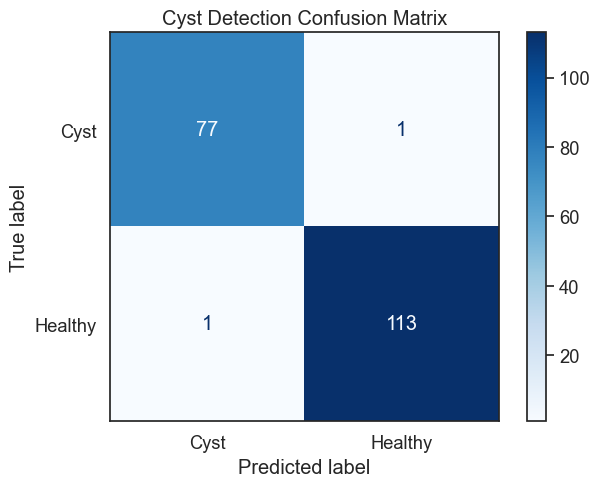

In [432]:
cm1 = confusion_matrix(dfval["true_label"], dfval["pred_label"])

disp = ConfusionMatrixDisplay(confusion_matrix=cm1, display_labels=['Cyst', 'Healthy'])
disp.plot(cmap=plt.cm.Blues)
plt.title("Cyst Detection Confusion Matrix")
plt.show()

## CNN Model

In [442]:
class CNNModel(nn.Module):
    def __init__(self, input_shape: Tuple[int, int, int] = (1, 224, 224), num_classes: int = 2,
                 pool_kernel1: int = 2, pool_kernel2: int = 2) -> None:
        super().__init__()

        self.pool_kernel1 = pool_kernel1
        self.pool_kernel2 = pool_kernel2

        self.c1 = nn.Conv2d(1, 8, kernel_size=3, padding=1)
        self.c2 = nn.Conv2d(8, 16, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool2d(kernel_size=pool_kernel1, stride=2)
        self.pool2 = nn.MaxPool2d(kernel_size=pool_kernel2, stride=2)

        with torch.no_grad():
            x = torch.zeros(1, *input_shape)
            x = self.pool1(F.relu(self.c1(x)))
            x = self.pool2(F.relu(self.c2(x)))
            n_features = x.view(1, -1).size(1)

        self.dense = nn.Linear(n_features, num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = F.relu(self.c1(x))
        x = self.pool1(x)
        x = F.relu(self.c2(x))
        x = self.pool2(x)
        x = x.view(x.size(0), -1)
        x = self.dense(x)
        return x

    def train_step(
        self,
        batch: Tuple[torch.Tensor, torch.Tensor],
        device: torch.device,
        criterion: nn.Module,
        optimizer: Optimizer
    ) -> float:
        self.train()
        data, targets = batch
        data, targets = data.to(device), targets.to(device)

        optimizer.zero_grad()
        scores = self(data)
        loss = criterion(scores, targets)
        loss.backward()
        optimizer.step()
        return loss.item()

    def validation_step(
        self,
        batch: Tuple[torch.Tensor, torch.Tensor],
        device: torch.device,
        criterion: nn.Module
    ) -> Tuple[float, float]:
        self.eval()
        data, targets = batch
        data, targets = data.to(device), targets.to(device)

        with torch.no_grad():
            scores = self(data)
            loss = criterion(scores, targets)
            _, preds = scores.max(1)
            accuracy = (preds == targets).sum().item() / data.size(0)

        return loss.item(), accuracy
    

In [456]:
class Evaluator:
    def __init__(
        self,
        model: nn.Module,
        train_loader: DataLoader,
        val_loader: DataLoader,
        device: Optional[torch.device] = None,
        lr: float = 1e-3,
        num_epochs: int = 10
    ):
        self.model = model
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.device = device or ("cuda" if torch.cuda.is_available() else "cpu")
        self.model.to(self.device)

        self.criterion = nn.CrossEntropyLoss()
        self.optimizer = optim.Adam(self.model.parameters(), lr=lr)
        self.num_epochs = num_epochs

        self.train_losses: List[float] = []
        self.val_losses: List[float] = []
        self.train_accs: List[float] = []
        self.val_accs: List[float] = []

    def reset_weights(self) -> None:
        """Reset model weights to start training from scratch."""
        def weight_reset(m: nn.Module) -> None:
            if isinstance(m, nn.Conv2d) or isinstance(m, nn.Linear):
                m.reset_parameters()
        self.model.apply(weight_reset)

        # Reset history
        self.train_losses = []
        self.val_losses = []
        self.train_accs = []
        self.val_accs = []

    def train_one_epoch(self) -> None:
        self.model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for batch in self.train_loader:
            data, targets = batch
            targets = 1 - targets
            data, targets = data.to(self.device), targets.to(self.device)

            self.optimizer.zero_grad()
            scores = self.model(data)
            loss = self.criterion(scores, targets)
            loss.backward()
            self.optimizer.step()

            running_loss += loss.item() * data.size(0)
            preds = scores.argmax(dim=1)
            correct += (preds == targets).sum().item()
            total += targets.size(0)

        epoch_loss = running_loss / total
        epoch_acc = correct / total
        self.train_losses.append(epoch_loss)
        self.train_accs.append(epoch_acc)

    def validate_one_epoch(self) -> Tuple[List[int], List[float]]:
        self.model.eval()
        running_loss = 0.0
        correct = 0
        total = 0
        all_targets: List[int] = []
        all_probs: List[float] = []

        with torch.no_grad():
            for batch in self.val_loader:
                data, targets = batch
                targets = 1 - targets
                data, targets = data.to(self.device), targets.to(self.device)

                scores = self.model(data)
                loss = self.criterion(scores, targets)

                running_loss += loss.item() * data.size(0)
                preds = scores.argmax(dim=1)
                correct += (preds == targets).sum().item()
                total += targets.size(0)

                all_targets.extend(targets.cpu().numpy())
                probs = torch.softmax(scores, dim=1)[:, 1]
                all_probs.extend(probs.cpu().numpy())

        epoch_loss = running_loss / total
        epoch_acc = correct / total
        self.val_losses.append(epoch_loss)
        self.val_accs.append(epoch_acc)

        return all_targets, all_probs

    def train(self) -> None:
        """Trains the model and prints metrics per epoch."""
        self.reset_weights()

        for epoch in range(self.num_epochs):
            self.train_one_epoch()
            all_targets, all_probs = self.validate_one_epoch()

            fpr, tpr, _ = roc_curve(all_targets, all_probs)
            roc_auc = auc(fpr, tpr)

            print(f"Epoch {epoch+1}/{self.num_epochs} | "
                  f"Train Acc: {100*self.train_accs[-1]:.2f}% | "
                  f"Val Acc: {100*self.val_accs[-1]:.2f}% | "
                  f"AUC: {roc_auc:.3f}")
            
            if self.val_accs[-1] >= 1:
                print(f"Validation accuracy reached 100% at epoch {epoch+1}. Stopping training.")
                break

    def plot_learning_curve(self) -> None:
        plt.figure(figsize=(12,5))

        plt.subplot(1, 2, 1)
        plt.plot(self.train_losses, label="Train Loss", marker='o')
        plt.plot(self.val_losses, label="Val Loss", marker='o')
        plt.title("Loss Curve")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.legend()
        plt.grid(True)

        plt.subplot(1, 2, 2)
        plt.plot([acc*100 for acc in self.train_accs], label="Train Acc", marker='o')
        plt.plot([acc*100 for acc in self.val_accs], label="Val Acc", marker='o')
        plt.title("Accuracy Curve")
        plt.xlabel("Epoch")
        plt.ylabel("Accuracy (%)")
        plt.legend()
        plt.grid(True)

        plt.tight_layout()
        plt.show()

    def plot_roc_curve(self) -> None:
        all_targets, all_probs = self.validate_one_epoch()
        fpr, tpr, _ = roc_curve(all_targets, all_probs)
        roc_auc = auc(fpr, tpr)

        plt.figure(figsize=(6,6))
        plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
        plt.plot([0,1],[0,1],'k--')
        plt.title("ROC Curve")
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.legend()
        plt.show()

    def plot_confusion_matrix(self) -> None:
        all_targets, all_probs = self.validate_one_epoch()
        preds = [1 if p>0.5 else 0 for p in all_probs]
        cm = confusion_matrix(all_targets, preds)
        disp = ConfusionMatrixDisplay(cm)
        disp.plot(cmap=plt.cm.Blues)
        plt.title("Confusion Matrix")
        plt.show()

    def run(self) -> None:
        """Run full training and evaluation pipeline."""
        print("Starting training...")
        self.train()
        print("Training complete. Plotting results...")
        self.plot_learning_curve()
        self.plot_roc_curve()
        self.plot_confusion_matrix()
        print("Evaluation complete.")

Starting training...
Epoch 1/10 | Train Acc: 77.63% | Val Acc: 90.62% | AUC: 0.975
Epoch 2/10 | Train Acc: 96.10% | Val Acc: 97.92% | AUC: 0.997
Epoch 3/10 | Train Acc: 99.67% | Val Acc: 99.48% | AUC: 0.999
Epoch 4/10 | Train Acc: 99.93% | Val Acc: 99.48% | AUC: 1.000
Epoch 5/10 | Train Acc: 100.00% | Val Acc: 99.48% | AUC: 1.000
Epoch 6/10 | Train Acc: 100.00% | Val Acc: 98.96% | AUC: 1.000
Epoch 7/10 | Train Acc: 100.00% | Val Acc: 98.96% | AUC: 1.000
Epoch 8/10 | Train Acc: 100.00% | Val Acc: 99.48% | AUC: 1.000
Epoch 9/10 | Train Acc: 100.00% | Val Acc: 99.48% | AUC: 1.000
Epoch 10/10 | Train Acc: 100.00% | Val Acc: 99.48% | AUC: 1.000
Training complete. Plotting results...


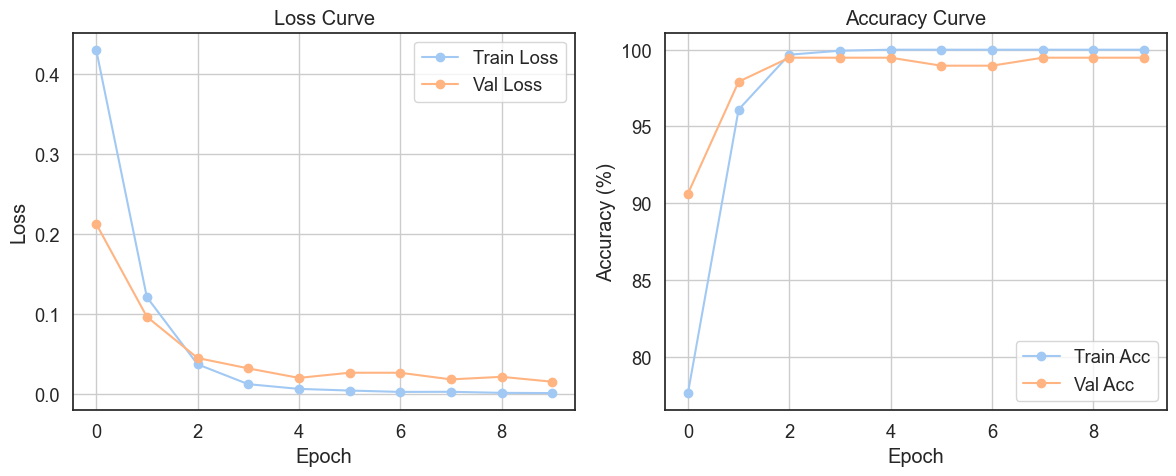

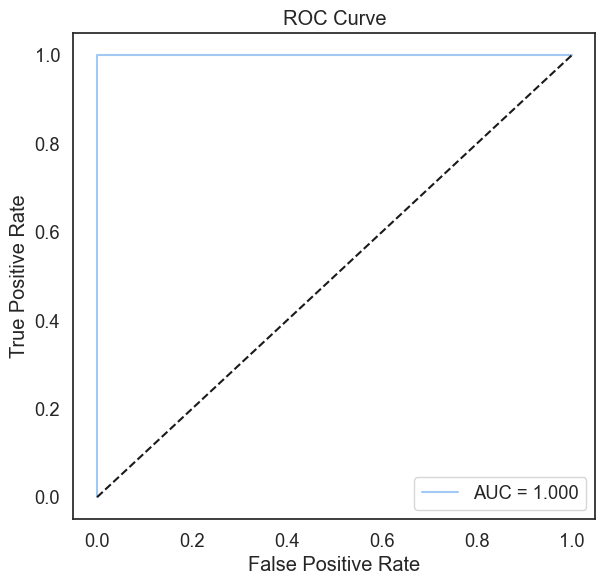

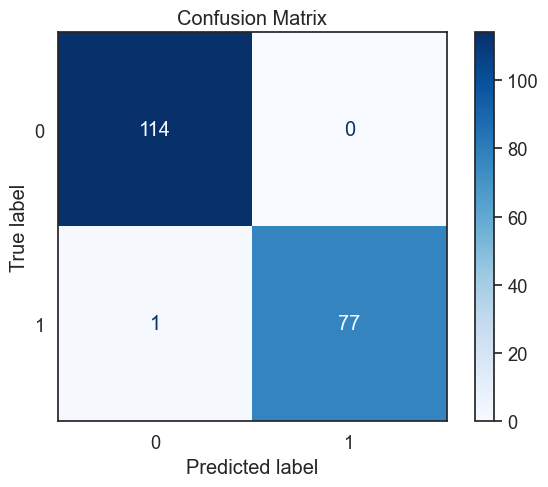

Evaluation complete.


In [457]:
train_loader = DataLoader(P.train_cnn, batch_size=64, shuffle=True)
val_loader = DataLoader(P.val_cnn, batch_size=64, shuffle=False)

device = "cuda" if torch.cuda.is_available() else "cpu"
model = CNNModel(input_shape=(1,224,224))

evaluator = Evaluator(model, train_loader, val_loader, device=device, num_epochs=10)
evaluator.run()

In [458]:
P28 = Prep(path, output_size=28)

Starting training...
Epoch 1/10 | Train Acc: 66.38% | Val Acc: 82.81% | AUC: 0.899
Epoch 2/10 | Train Acc: 79.65% | Val Acc: 86.46% | AUC: 0.893
Epoch 3/10 | Train Acc: 85.05% | Val Acc: 86.98% | AUC: 0.915
Epoch 4/10 | Train Acc: 87.13% | Val Acc: 86.46% | AUC: 0.943
Epoch 5/10 | Train Acc: 89.27% | Val Acc: 88.54% | AUC: 0.961
Epoch 6/10 | Train Acc: 90.83% | Val Acc: 89.06% | AUC: 0.976
Epoch 7/10 | Train Acc: 90.77% | Val Acc: 93.75% | AUC: 0.986
Epoch 8/10 | Train Acc: 93.76% | Val Acc: 94.79% | AUC: 0.990
Epoch 9/10 | Train Acc: 94.86% | Val Acc: 95.83% | AUC: 0.994
Epoch 10/10 | Train Acc: 96.03% | Val Acc: 96.35% | AUC: 0.997
Training complete. Plotting results...


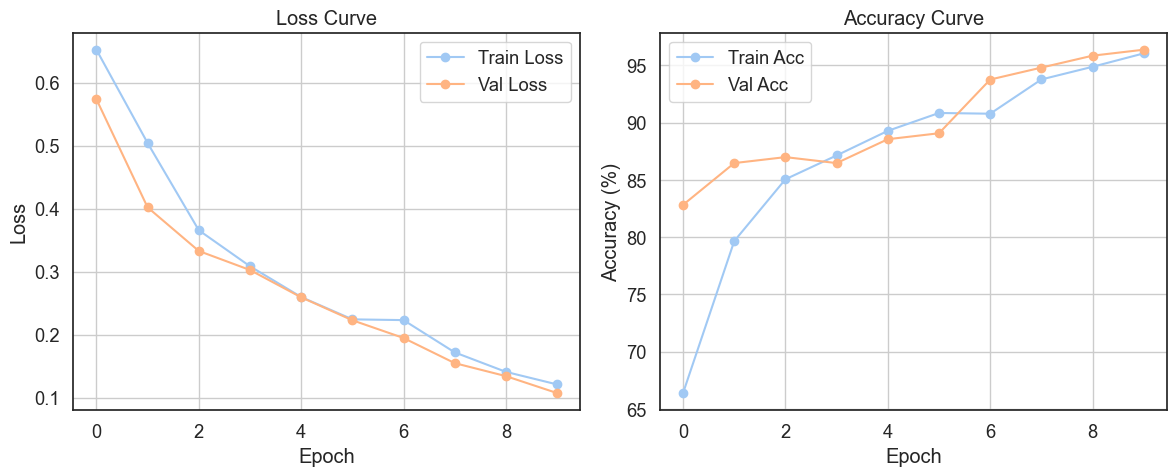

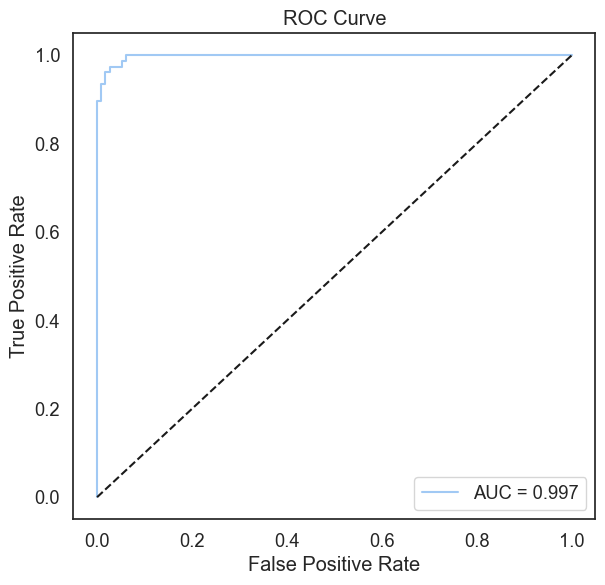

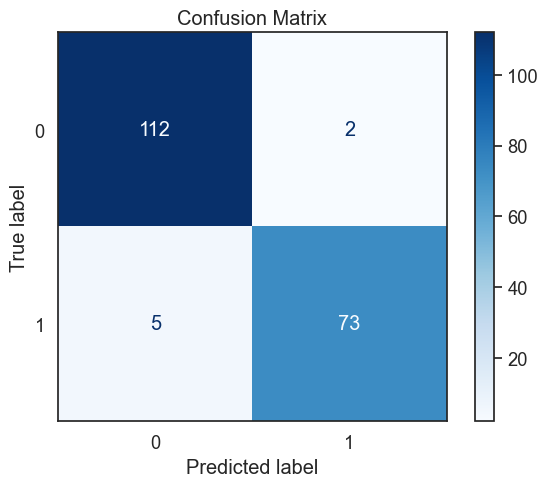

Evaluation complete.


In [461]:
train_loader28 = DataLoader(P28.train_cnn, batch_size=64, shuffle=True)
val_loader28 = DataLoader(P28.val_cnn, batch_size=64, shuffle=False)

device = "cuda" if torch.cuda.is_available() else "cpu"
model28 = CNNModel(input_shape=(1,28,28))

evaluator28 = Evaluator(model28, train_loader28, val_loader28, device=device, num_epochs=10)
evaluator28.run()

In [462]:
P16 = Prep(path, 16)

Starting training...
Epoch 1/15 | Train Acc: 64.30% | Val Acc: 84.38% | AUC: 0.938
Epoch 2/15 | Train Acc: 85.50% | Val Acc: 87.50% | AUC: 0.931
Epoch 3/15 | Train Acc: 86.28% | Val Acc: 87.50% | AUC: 0.937
Epoch 4/15 | Train Acc: 88.49% | Val Acc: 90.10% | AUC: 0.961
Epoch 5/15 | Train Acc: 92.26% | Val Acc: 93.23% | AUC: 0.983
Epoch 6/15 | Train Acc: 92.98% | Val Acc: 95.83% | AUC: 0.994
Epoch 7/15 | Train Acc: 94.54% | Val Acc: 95.31% | AUC: 0.996
Epoch 8/15 | Train Acc: 95.19% | Val Acc: 94.79% | AUC: 0.997
Epoch 9/15 | Train Acc: 96.49% | Val Acc: 94.79% | AUC: 0.999
Epoch 10/15 | Train Acc: 97.33% | Val Acc: 97.40% | AUC: 0.999
Epoch 11/15 | Train Acc: 97.20% | Val Acc: 98.96% | AUC: 1.000
Epoch 12/15 | Train Acc: 97.98% | Val Acc: 98.44% | AUC: 1.000
Epoch 13/15 | Train Acc: 98.24% | Val Acc: 98.96% | AUC: 1.000
Epoch 14/15 | Train Acc: 98.31% | Val Acc: 98.96% | AUC: 1.000
Epoch 15/15 | Train Acc: 98.18% | Val Acc: 100.00% | AUC: 1.000
Validation accuracy reached 100% at epoch 

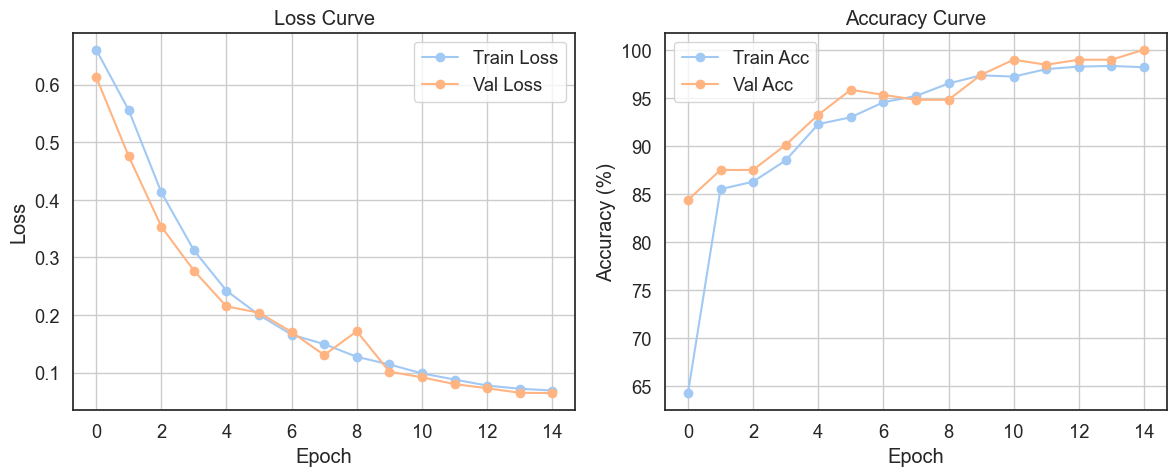

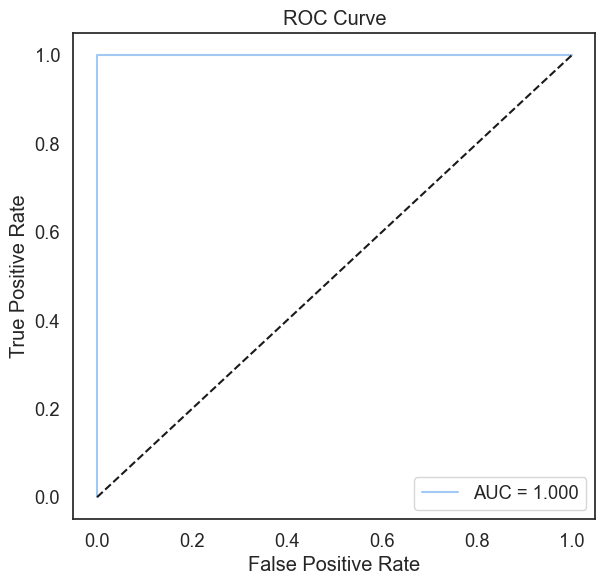

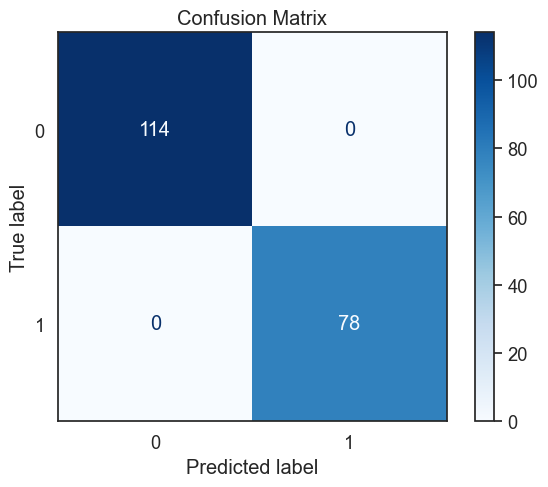

Evaluation complete.


In [463]:
train_loader16 = DataLoader(P16.train_cnn, batch_size=64, shuffle=True)
val_loader16 = DataLoader(P16.val_cnn, batch_size=64, shuffle=False)

device = "cuda" if torch.cuda.is_available() else "cpu"
model16 = CNNModel(input_shape=(1,16,16))

evaluator16 = Evaluator(model16, train_loader16, val_loader16, device=device, num_epochs=15)
evaluator16.run()

In [453]:
MM28 = ManualModel(P28.train_cv)
df28 = MM28.infer_labels()
MM28.evaluate(df28)

0.5936280884265279

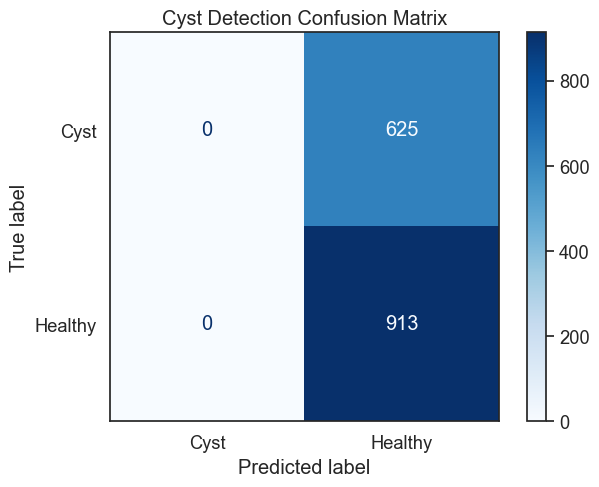

In [454]:
cm28 = confusion_matrix(df28["true_label"], df28["pred_label"])

disp = ConfusionMatrixDisplay(confusion_matrix=cm28, display_labels=['Cyst', 'Healthy'])
disp.plot(cmap=plt.cm.Blues)
plt.title("Cyst Detection Confusion Matrix")
plt.show()

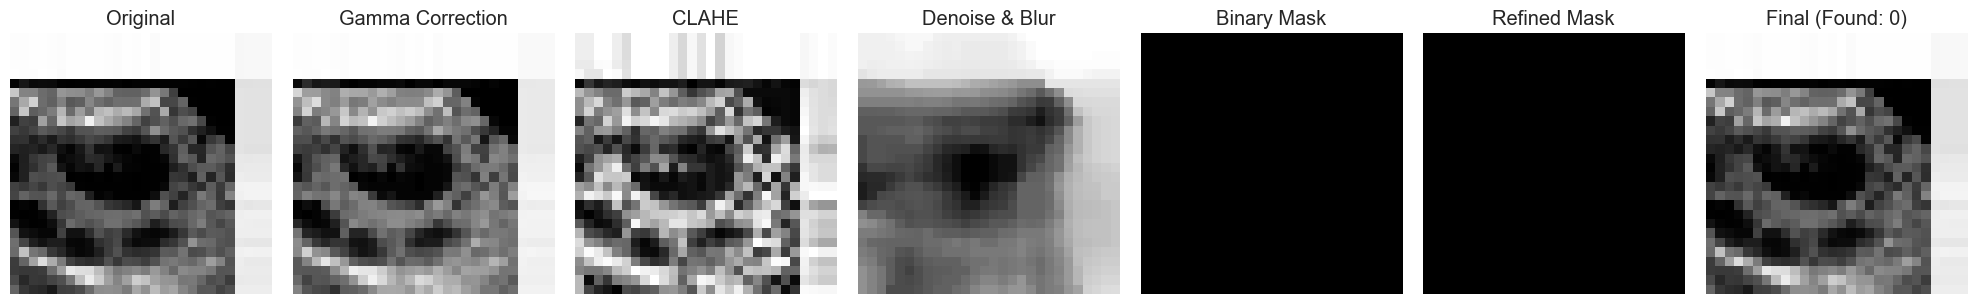

Detected 0 potential cysts.
True label: 0


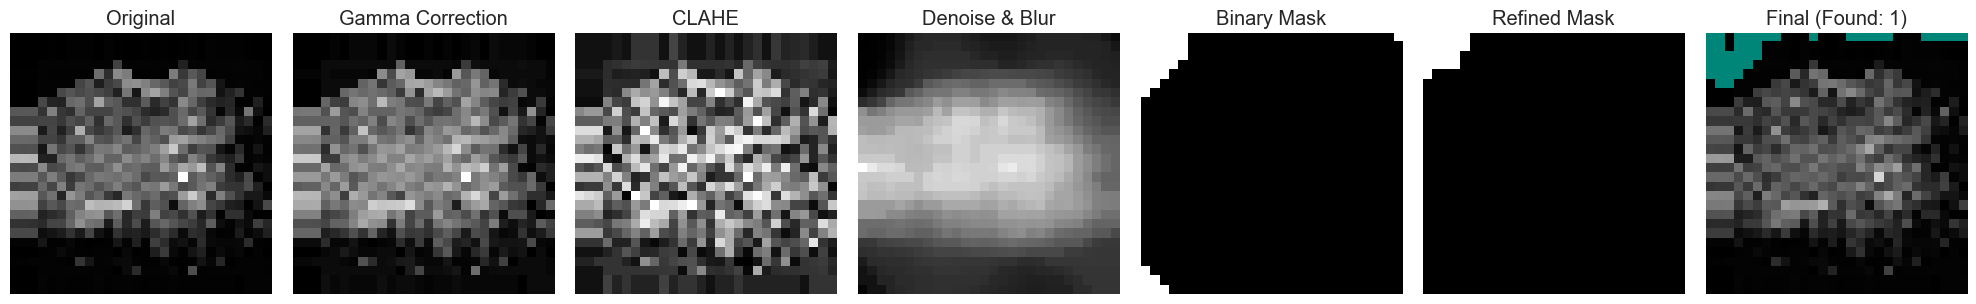

Detected 1 potential cysts.
True label: 1


In [452]:
engine28 = Annotate()

img, label = P28.train_cv[0] 
result_img, cyst_count = engine28.apply_pipeline(img, plot=True)

print(f"Detected {cyst_count} potential cysts.")
print(f"True label: {label}")

img, label = P28.train_cv[-1] 
result_img, cyst_count = engine28.apply_pipeline(img, plot=True)

print(f"Detected {cyst_count} potential cysts.")
print(f"True label: {label}")